In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import seaborn as sns

# from posydon.popsyn.binarypopulation import BinaryPopulation
# from posydon.binary_evol.binarystar import BinaryStar
# from posydon.binary_evol.singlestar import SingleStar
from posydon.popsyn.synthetic_population import Population
# from posydon.popsyn.synthetic_population import PopulationRunner
# import astropy.units as u
# 
# import os
# import shutil
# from posydon.config import PATH_TO_POSYDON

from POSYDONHRDiagramModule import HR_Diagram

import matplotlib.pyplot as plt
import matplotlib as mpl

import random as rand 

from collections import Counter

DataPath = Path().resolve().parent / 'Data'


In [2]:
cols = ['time', 'step_names', 'state', 'event', 'S1_state', 'S2_state', 'S1_mass', 'S2_mass', 'orbital_period']
finCols = [
    'orbital_period_f',
    'eccentricity_f',
    'state_f',

    'S1_state_f',
    'S2_state_f',
    
    'S2_mass_f',
    'S2_log_R_f',
    'S2_log_L_f',


    'S1_mass_f',
    'S1_log_R_f',
    'S1_log_L_f'

 ]

initCols = [
    'orbital_period_i',
    'eccentricity_i',
    'state_i',

    'S2_state_i',
    'S2_mass_i',
    'S2_log_R_i',

    'S1_state_i',
    'S1_mass_i',
    'S1_log_R_i'
 ]

In [3]:
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",  
    "font.family": "serif",       
    "text.usetex": True,          
    "pgf.rcfonts": False,         
})

In [4]:
def basicColHist(df, var: str, title: str | None = None, xLabel: str | None = None, saveFig: bool = False, savePath: Path = Path()) -> None:
    fig, ax = plt.subplots(figsize=(8,5))
    
    sns.histplot(df[var], bins=50, ax=ax)
    
    if title is None:
        title = f'{var} of BH-Sol systems at S1 SN'
    if xLabel is None:
        xLabel = var

    ax.set_title(title)
    ax.set_xlabel(xLabel)
    ax.set_ylabel('Count')

    if saveFig:
        clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
        plt.savefig(savePath / clean_name, bbox_inches='tight')

    plt.show()

def genVarHist(var: list, title: str | None = None, xLabel: str | None = None, saveFig: bool = False, savePath: Path = Path()) -> None:
    fig, ax = plt.subplots(figsize=(8,5))
    
    sns.histplot(var, bins=50, ax=ax)
    
    if title is None:
        title = 'default'
    if xLabel is None:
        xLabel = 'default'

    ax.set_title(title)
    ax.set_xlabel(xLabel)
    ax.set_ylabel('Count')

    if saveFig:
        clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
        plt.savefig(savePath / clean_name, bbox_inches='tight')

    plt.show()

In [ ]:
def xVsY(
    xvar: str|list, yvar: str|list,
    df: pd.DataFrame | None = None,
    useDF: bool = True, 
    title: str | None = None,
    xLabel: str | None = None,
    yLabel: str | None = None,
    saveFig: bool = False,
    savePath: Path = Path(),
    fit: bool = False,
    ci: int = 95
) -> None:
    fig, ax = plt.subplots(figsize=(8, 5))

    if useDF:
        x = df[xvar] if isinstance(xvar, str) else xvar
        y = df[yvar] if isinstance(yvar, str) else yvar
    else:
        x, y = xvar, yvar  
        
    if fit:
        sns.regplot(x=x, y=y, ci=ci, ax=ax,
                    line_kws={"color": "red", "linestyle": "--", "linewidth": 2},
                    scatter_kws={"alpha": 0.6})
    else:
        sns.scatterplot(x=x, y=y, alpha=0.6, ax=ax)

    if title is None:
        if isinstance(xvar, str) and isinstance(yvar, str):
            title = f'{xvar} vs {yvar} of BH-Sol systems at S1 SN'
        else:
            title = 'Variable Comparison'

    if xLabel is None:
        xLabel = xvar if isinstance(xvar, str) else 'X-Axis'
        
    if yLabel is None:
        yLabel = yvar if isinstance(yvar, str) else 'Y-Axis'

    ax.set_title(title)
    ax.set_xlabel(xLabel)
    ax.set_ylabel(yLabel)

    if saveFig:
        clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
        plt.savefig(savePath / clean_name, bbox_inches='tight')

    plt.show()

In [6]:
pop = Population(str(DataPath / 'SunLikeStar_Filt' / 'BH_Sol_Filtered_1e+00_Zsun_population.h5'))

In [7]:
bhSolRows = pd.read_csv(DataPath /'SunLikeStar_Filt' / 'BH_Sol_Filtered_1e+00_Zsun_population.csv')

In [8]:
bhSolRows = bhSolRows.drop(17, axis='index')

In [9]:
bhSolRows

,binary_index,state,event,time,orbital_period,eccentricity,lg_mtransfer_rate,step_names,step_times,S1_state,...,S2_he_core_mass,S2_he_core_radius,S2_co_core_mass,S2_co_core_radius,S2_center_h1,S2_center_he4,S2_surface_h1,S2_surface_he4,S2_surf_avg_omega_div_omega_crit,S2_spin
0,22892,detached,NaN,4.498900e+09,1.494220,0.360938,NaN,step_SN,0.002222,BH,...,0.0,NaN,0.0,0.0,0.691616,0.294023,0.7155,0.270271,0.105856,3.023514
1,30640,detached,NaN,8.381730e+09,1.884652,0.142856,NaN,step_SN,0.004856,BH,...,0.0,NaN,0.0,0.0,0.696244,0.289355,0.7155,0.270271,0.125305,3.578513
2,98004,detached,NaN,9.548856e+09,2.740360,0.351989,NaN,step_SN,0.003183,BH,...,0.0,NaN,0.0,0.0,0.695545,0.290039,0.7155,0.270271,0.097579,2.769272
3,152104,detached,NaN,2.025330e+09,0.796016,0.669528,NaN,step_SN,0.001699,BH,...,0.0,NaN,0.0,0.0,0.705203,0.280193,0.7155,0.270271,0.032131,0.904615
4,197243,detached,NaN,8.824689e+09,3.317456,0.600119,NaN,step_SN,0.002589,BH,...,0.0,NaN,0.0,0.0,0.695127,0.290483,0.7155,0.270271,0.080369,2.296414
5,214571,detached,NaN,9.934345e+09,6.844816,0.716792,NaN,step_SN,0.003830,BH,...,0.0,NaN,0.0,0.0,0.701769,0.283705,0.7155,0.270271,0.033424,0.937796
6,217672,detached,NaN,9.226441e+09,7.859836,0.598014,NaN,step_SN,0.003460,BH,...,0.0,NaN,0.0,0.0,0.704175,0.281255,0.7155,0.270271,0.030181,0.845591
7,227670,detached,NaN,3.143854e+08,52.749603,0.663875,NaN,step_SN,0.004207,BH,...,0.0,NaN,0.0,0.0,0.698373,0.287186,0.7155,0.270271,0.039821,1.129760
8,234637,detached,NaN,8.256869e+09,15.899186,0.622247,NaN,step_SN,0.004924,BH,...,0.0,NaN,0.0,0.0,0.696121,0.289475,0.7155,0.270271,0.050934,1.452895
9,271714,detached,NaN,7.629761e+09,14.974814,0.357936,NaN,step_SN,0.003989,BH,...,0.0,NaN,0.0,0.0,0.696206,0.289376,0.7155,0.270271,0.048040,1.364186


In [10]:
# pop.calculate_formation_channels()

In [11]:
Counter(pop.formation_channels['channel'])

Counter({'ZAMS_oCE1_CC1_oRLO2_CC2_maxtime_END': 35,
         'ZAMS_oCE1_CC1_oRLO2_maxtime_END': 7,
         'ZAMS_oCE1_CC1_END': 3,
         'ZAMS_oRLO1_CC1_oRLO2_CC2_FAILED': 1})

In [12]:
pOneline = pop.oneline.select()
pHistory = pop.history.select()

In [13]:
pOneline = pOneline.drop(17, axis='index')
pHistory = pHistory.drop(17, axis='index')


In [34]:
bhSolRows

,binary_index,state,event,time,orbital_period,eccentricity,lg_mtransfer_rate,step_names,step_times,S1_state,...,S2_he_core_mass,S2_he_core_radius,S2_co_core_mass,S2_co_core_radius,S2_center_h1,S2_center_he4,S2_surface_h1,S2_surface_he4,S2_surf_avg_omega_div_omega_crit,S2_spin
0,22892,detached,NaN,4.498900e+09,1.494220,0.360938,NaN,step_SN,0.002222,BH,...,0.0,NaN,0.0,0.0,0.691616,0.294023,0.7155,0.270271,0.105856,3.023514
1,30640,detached,NaN,8.381730e+09,1.884652,0.142856,NaN,step_SN,0.004856,BH,...,0.0,NaN,0.0,0.0,0.696244,0.289355,0.7155,0.270271,0.125305,3.578513
2,98004,detached,NaN,9.548856e+09,2.740360,0.351989,NaN,step_SN,0.003183,BH,...,0.0,NaN,0.0,0.0,0.695545,0.290039,0.7155,0.270271,0.097579,2.769272
3,152104,detached,NaN,2.025330e+09,0.796016,0.669528,NaN,step_SN,0.001699,BH,...,0.0,NaN,0.0,0.0,0.705203,0.280193,0.7155,0.270271,0.032131,0.904615
4,197243,detached,NaN,8.824689e+09,3.317456,0.600119,NaN,step_SN,0.002589,BH,...,0.0,NaN,0.0,0.0,0.695127,0.290483,0.7155,0.270271,0.080369,2.296414
5,214571,detached,NaN,9.934345e+09,6.844816,0.716792,NaN,step_SN,0.003830,BH,...,0.0,NaN,0.0,0.0,0.701769,0.283705,0.7155,0.270271,0.033424,0.937796
6,217672,detached,NaN,9.226441e+09,7.859836,0.598014,NaN,step_SN,0.003460,BH,...,0.0,NaN,0.0,0.0,0.704175,0.281255,0.7155,0.270271,0.030181,0.845591
7,227670,detached,NaN,3.143854e+08,52.749603,0.663875,NaN,step_SN,0.004207,BH,...,0.0,NaN,0.0,0.0,0.698373,0.287186,0.7155,0.270271,0.039821,1.129760
8,234637,detached,NaN,8.256869e+09,15.899186,0.622247,NaN,step_SN,0.004924,BH,...,0.0,NaN,0.0,0.0,0.696121,0.289475,0.7155,0.270271,0.050934,1.452895
9,271714,detached,NaN,7.629761e+09,14.974814,0.357936,NaN,step_SN,0.003989,BH,...,0.0,NaN,0.0,0.0,0.696206,0.289376,0.7155,0.270271,0.048040,1.364186


In [15]:
pOneline[pOneline['S2_mass_i'] > 3]

,state_i,event_i,time_i,orbital_period_i,eccentricity_i,lg_mtransfer_rate_i,step_names_i,step_times_i,S1_state_i,S1_mass_i,...,interp_class_CO_HMS_RLO,interp_class_CO_HeMS,interp_class_CO_HeMS_RLO,mt_history_HMS_HMS,mt_history_CO_HMS_RLO,mt_history_CO_HeMS,mt_history_CO_HeMS_RLO,FAILED,WARNING,metallicity
binary_index,,,,,,,,,,,,,,,,,,,,,


In [16]:
print(((pOneline['orbital_period_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

\begin{tabular}{|l|r|}
 & orbital\_period\_i \\
count & 45.000000 \\
mean & 4150.149389 \\
std & 158.999350 \\
min & 3844.570082 \\
25\% & 4016.808617 \\
50\% & 4170.976368 \\
75\% & 4273.375834 \\
max & 4390.052803 \\
\end{tabular}



In [17]:
print(((pOneline['S2_mass_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

\begin{tabular}{|l|r|}
 & S2\_mass\_i \\
count & 45.000000 \\
mean & 2.195909 \\
std & 0.348479 \\
min & 1.551266 \\
25\% & 1.880662 \\
50\% & 2.188940 \\
75\% & 2.474821 \\
max & 2.753904 \\
\end{tabular}



In [18]:
print(((pOneline['S1_mass_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

\begin{tabular}{|l|r|}
 & S1\_mass\_i \\
count & 45.000000 \\
mean & 16.826121 \\
std & 1.107231 \\
min & 14.878710 \\
25\% & 16.077692 \\
50\% & 16.665842 \\
75\% & 17.672163 \\
max & 19.435080 \\
\end{tabular}



In [19]:
pOneline['eccentricity_f'].describe()

count    45.000000
mean      0.044134
std       0.167015
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.669528
Name: eccentricity_f, dtype: float64

In [20]:
graphSave = Path.cwd().parent / 'Reports' /'3_23_26' / 'graphs'

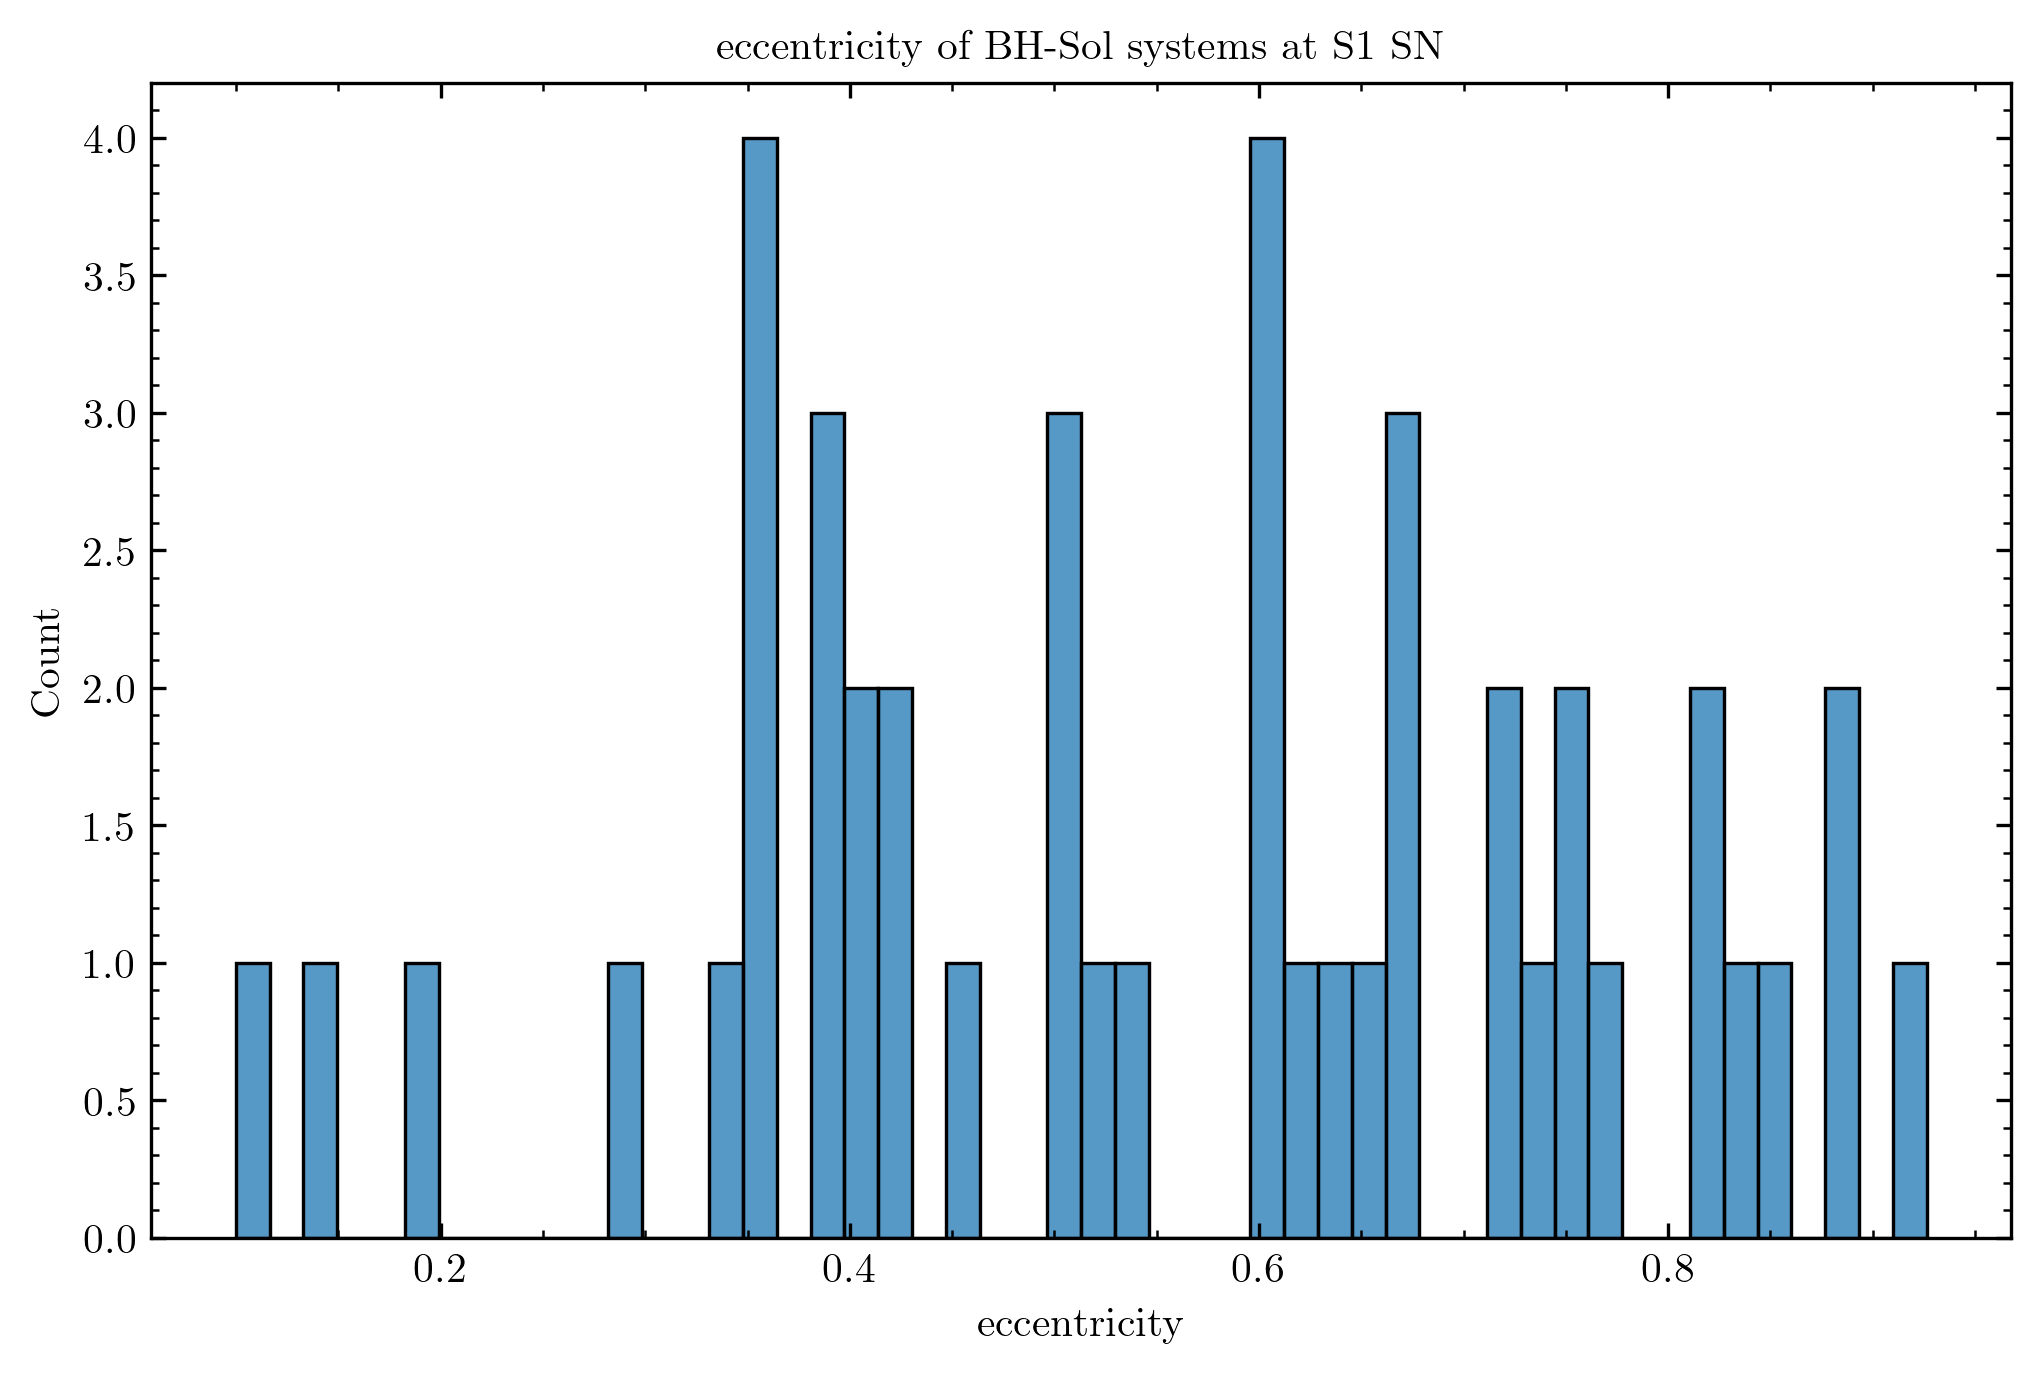

In [21]:
basicColHist(bhSolRows, 'eccentricity')

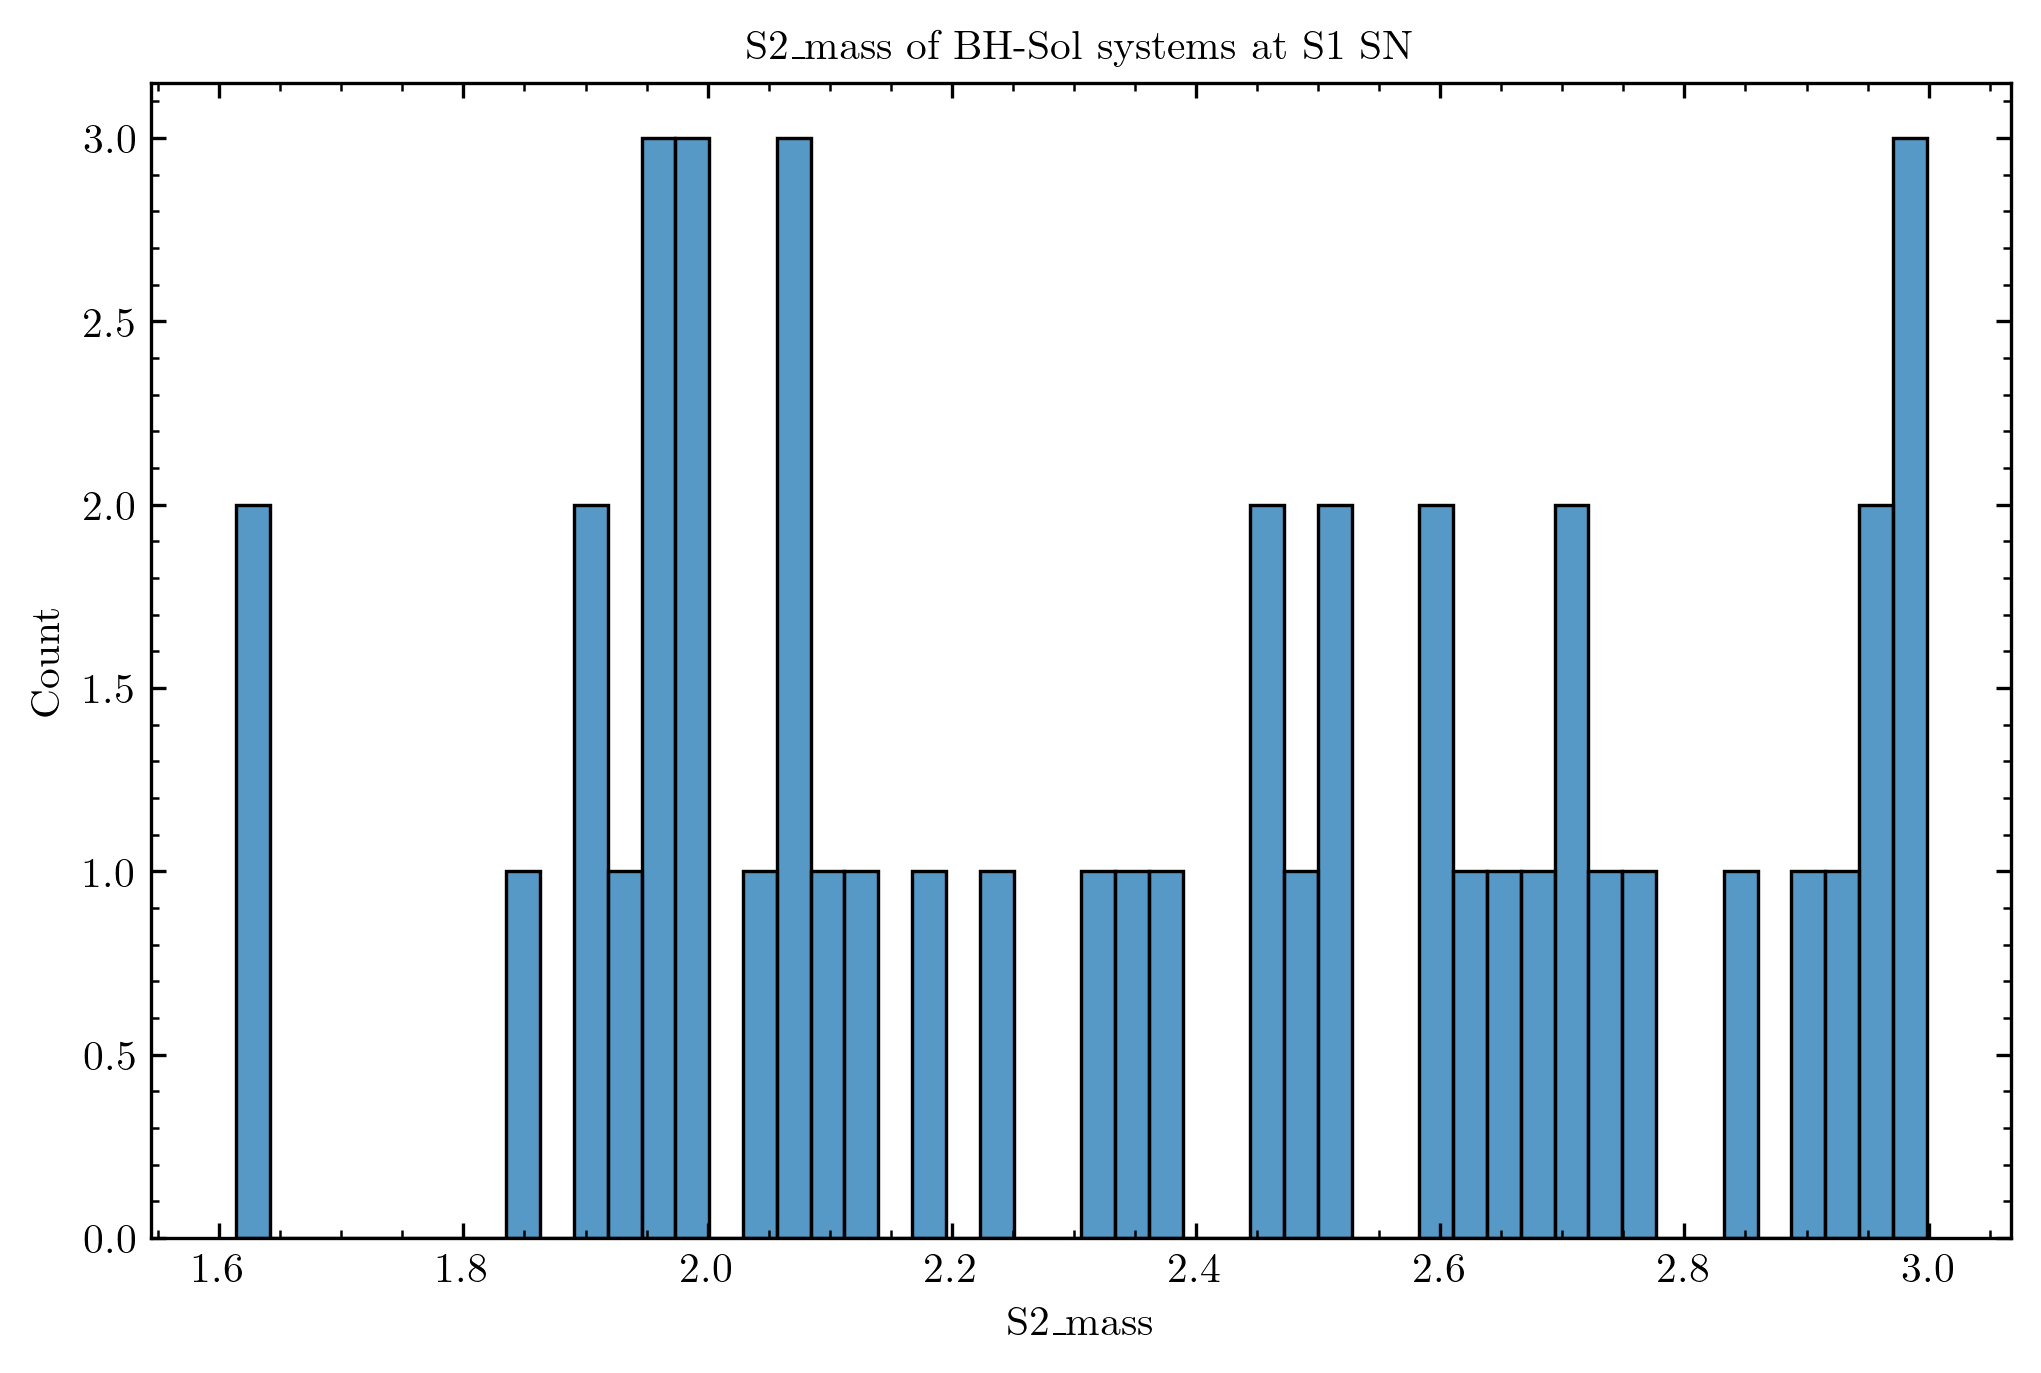

In [22]:
basicColHist(bhSolRows,'S2_mass')

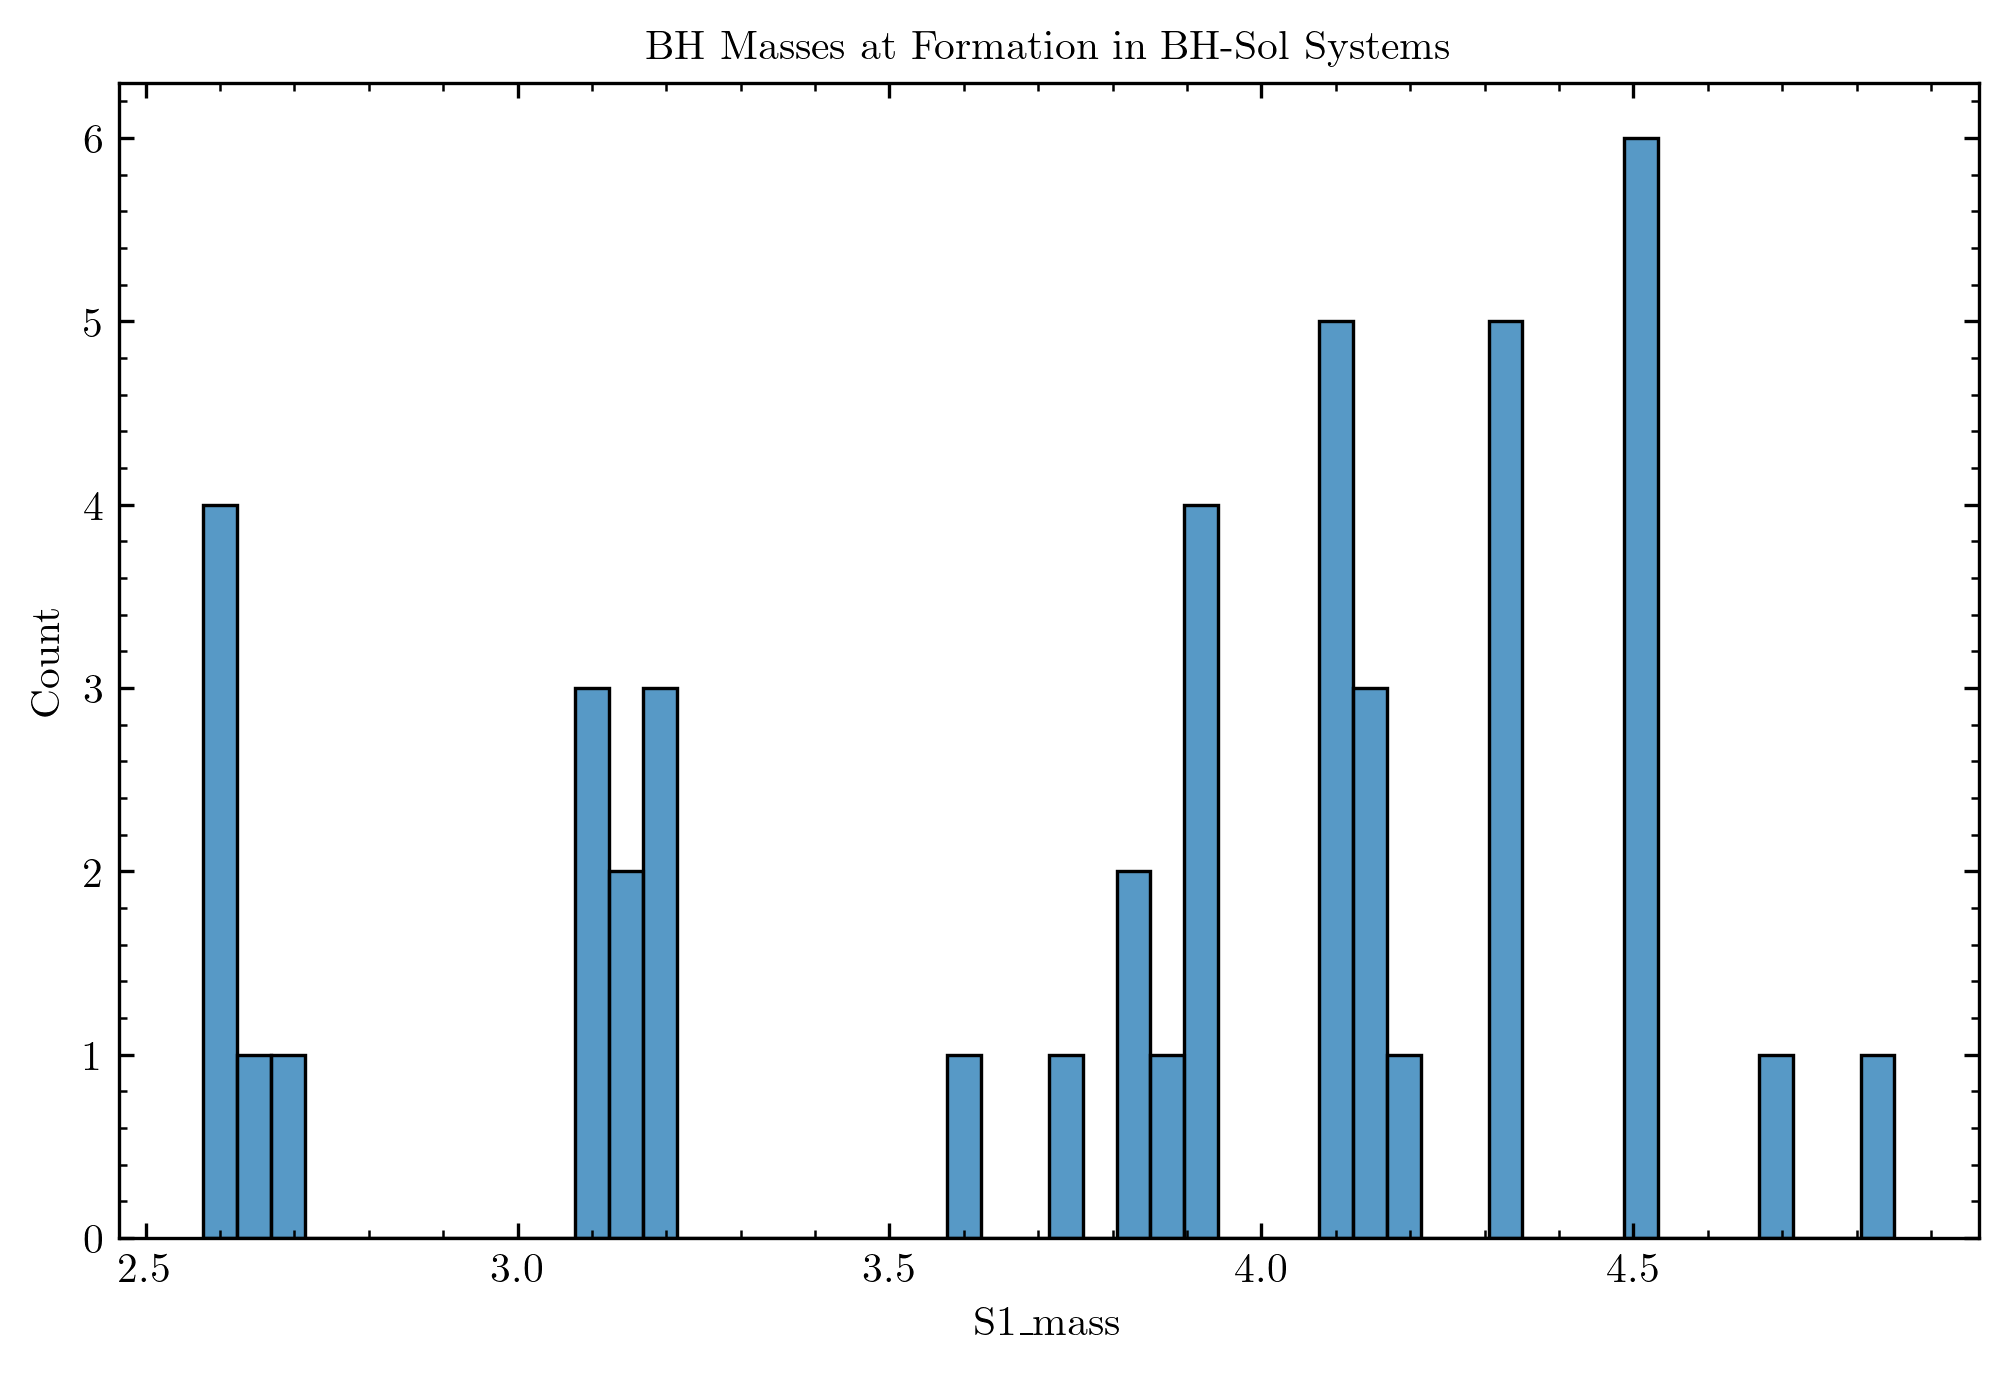

In [23]:
basicColHist(bhSolRows,'S1_mass', title='BH Masses at Formation in BH-Sol Systems')

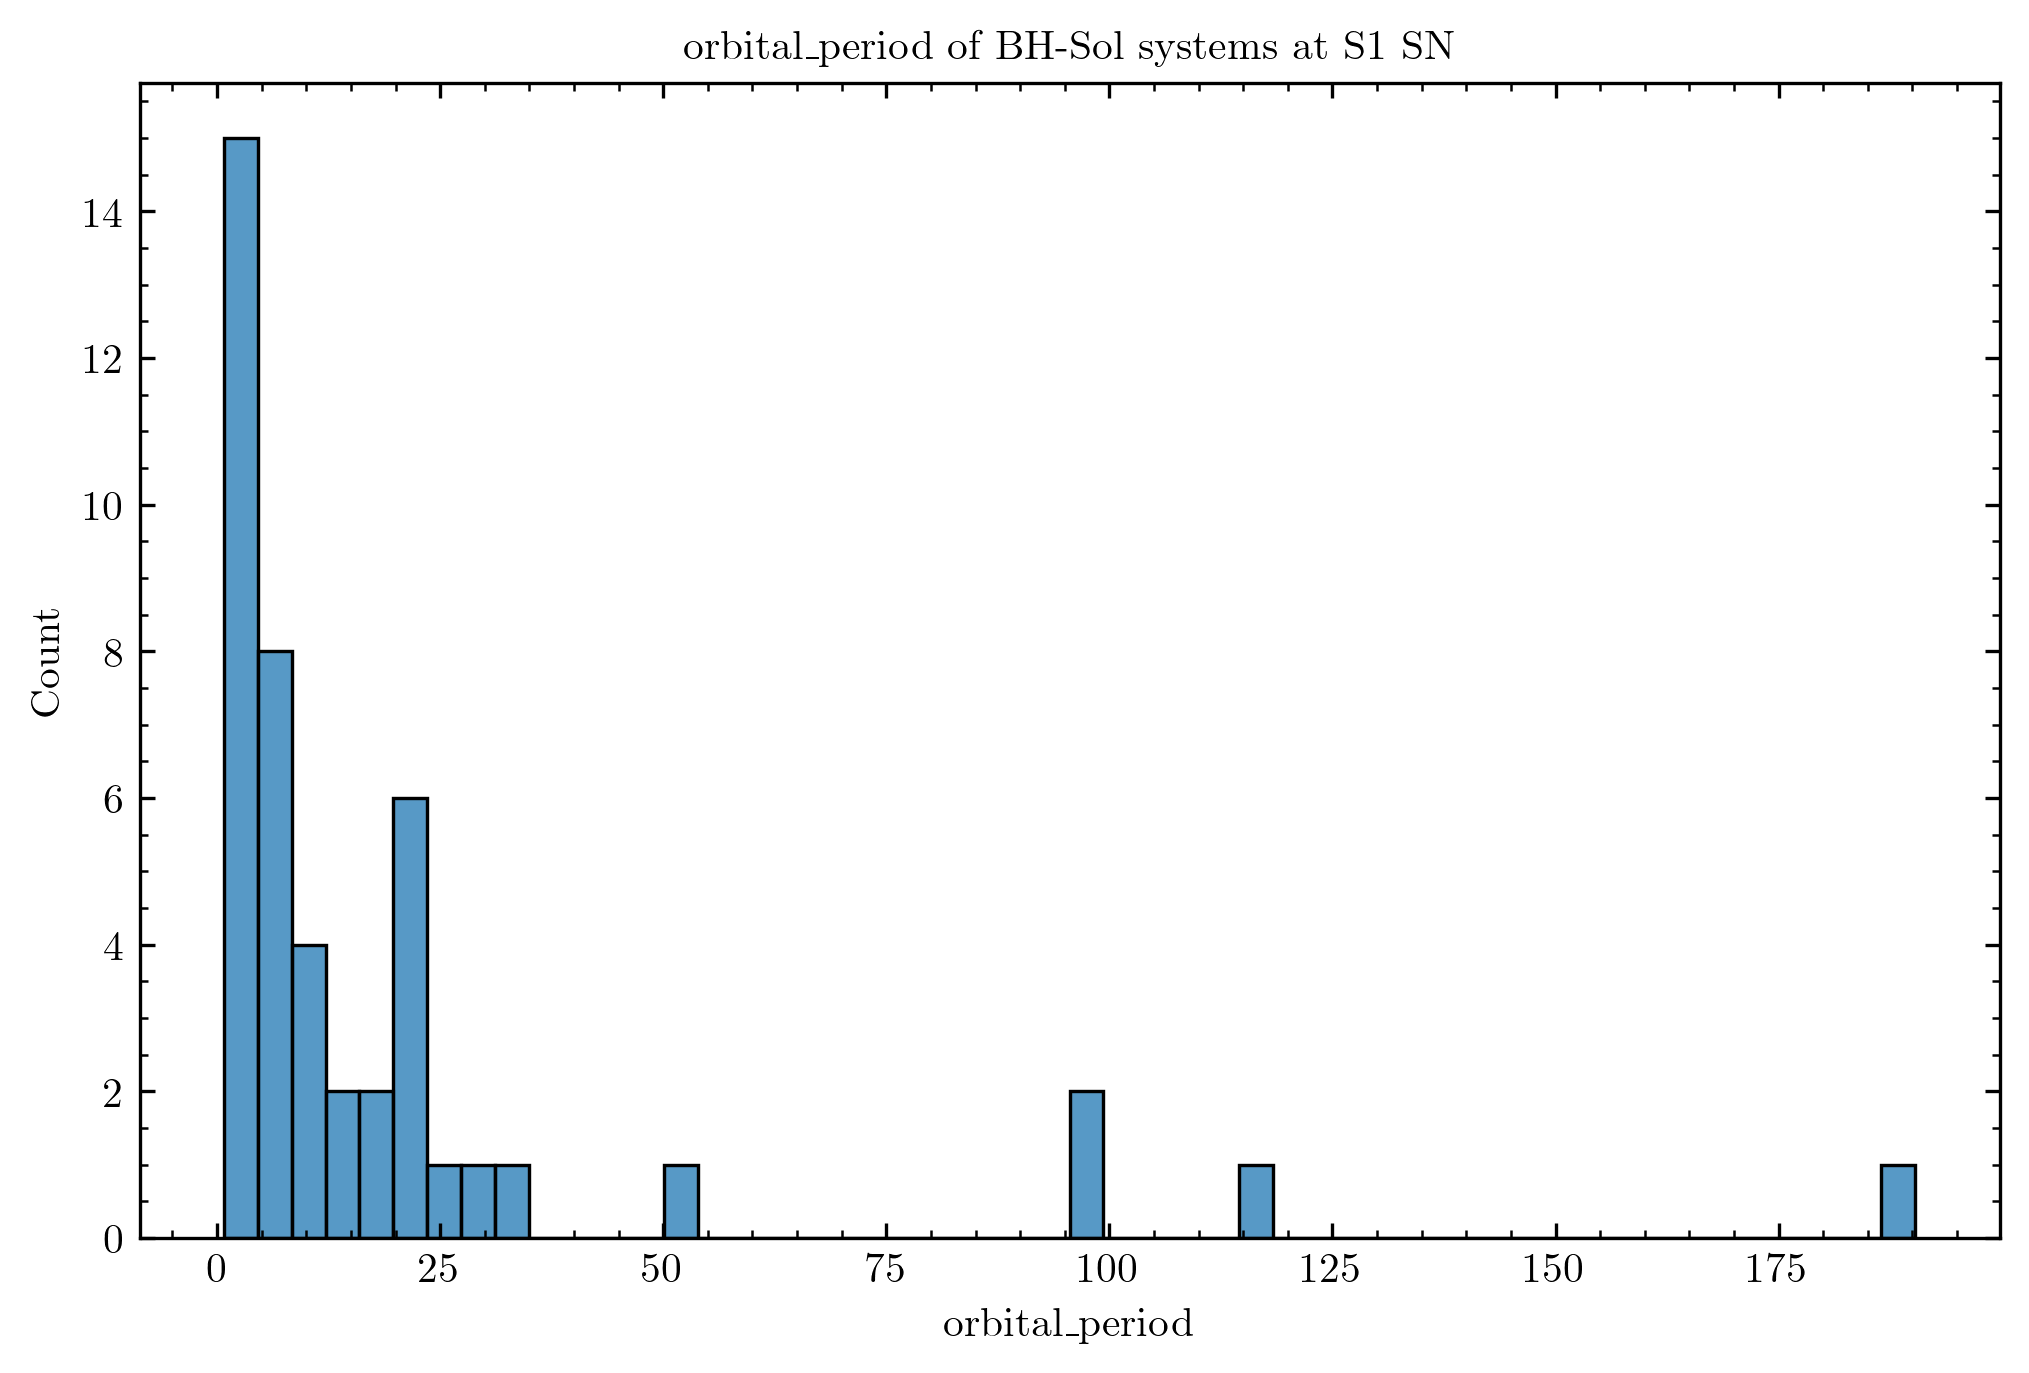

In [24]:
basicColHist(bhSolRows,'orbital_period', saveFig=True, savePath=graphSave)

In [25]:
slimOP = bhSolRows[bhSolRows['orbital_period'] < 25]['orbital_period']

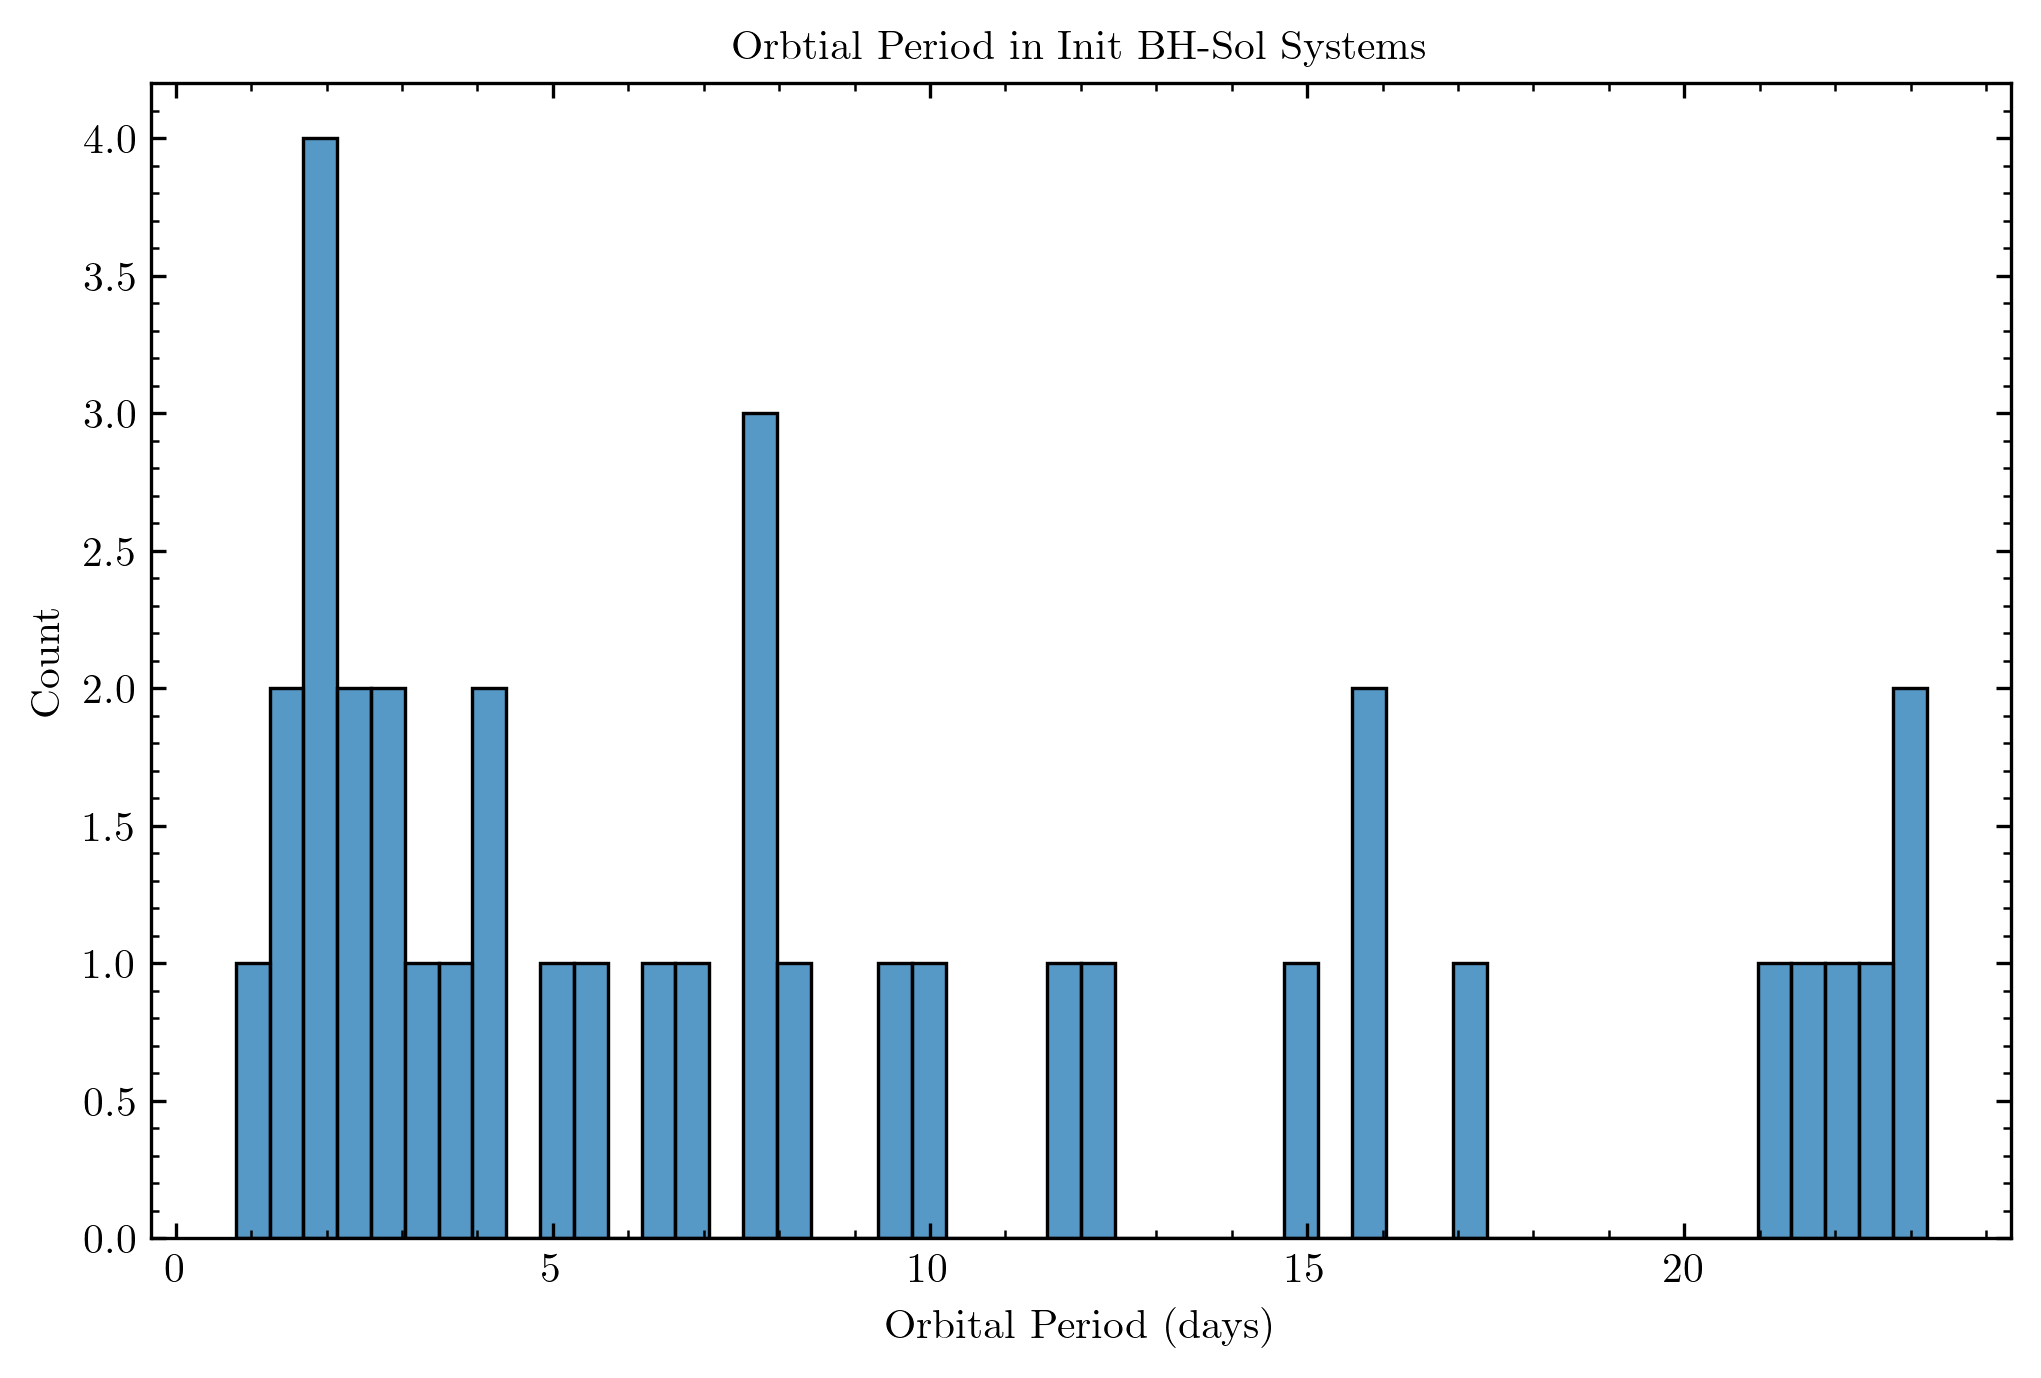

In [26]:
genVarHist(slimOP, title='Orbtial Period in Init BH-Sol Systems', xLabel='Orbital Period (days)', saveFig=True, savePath=graphSave)

In [27]:
# HR_Diagram(bhSolRows,
#            'BhSol',
#            Star_Radius=15)

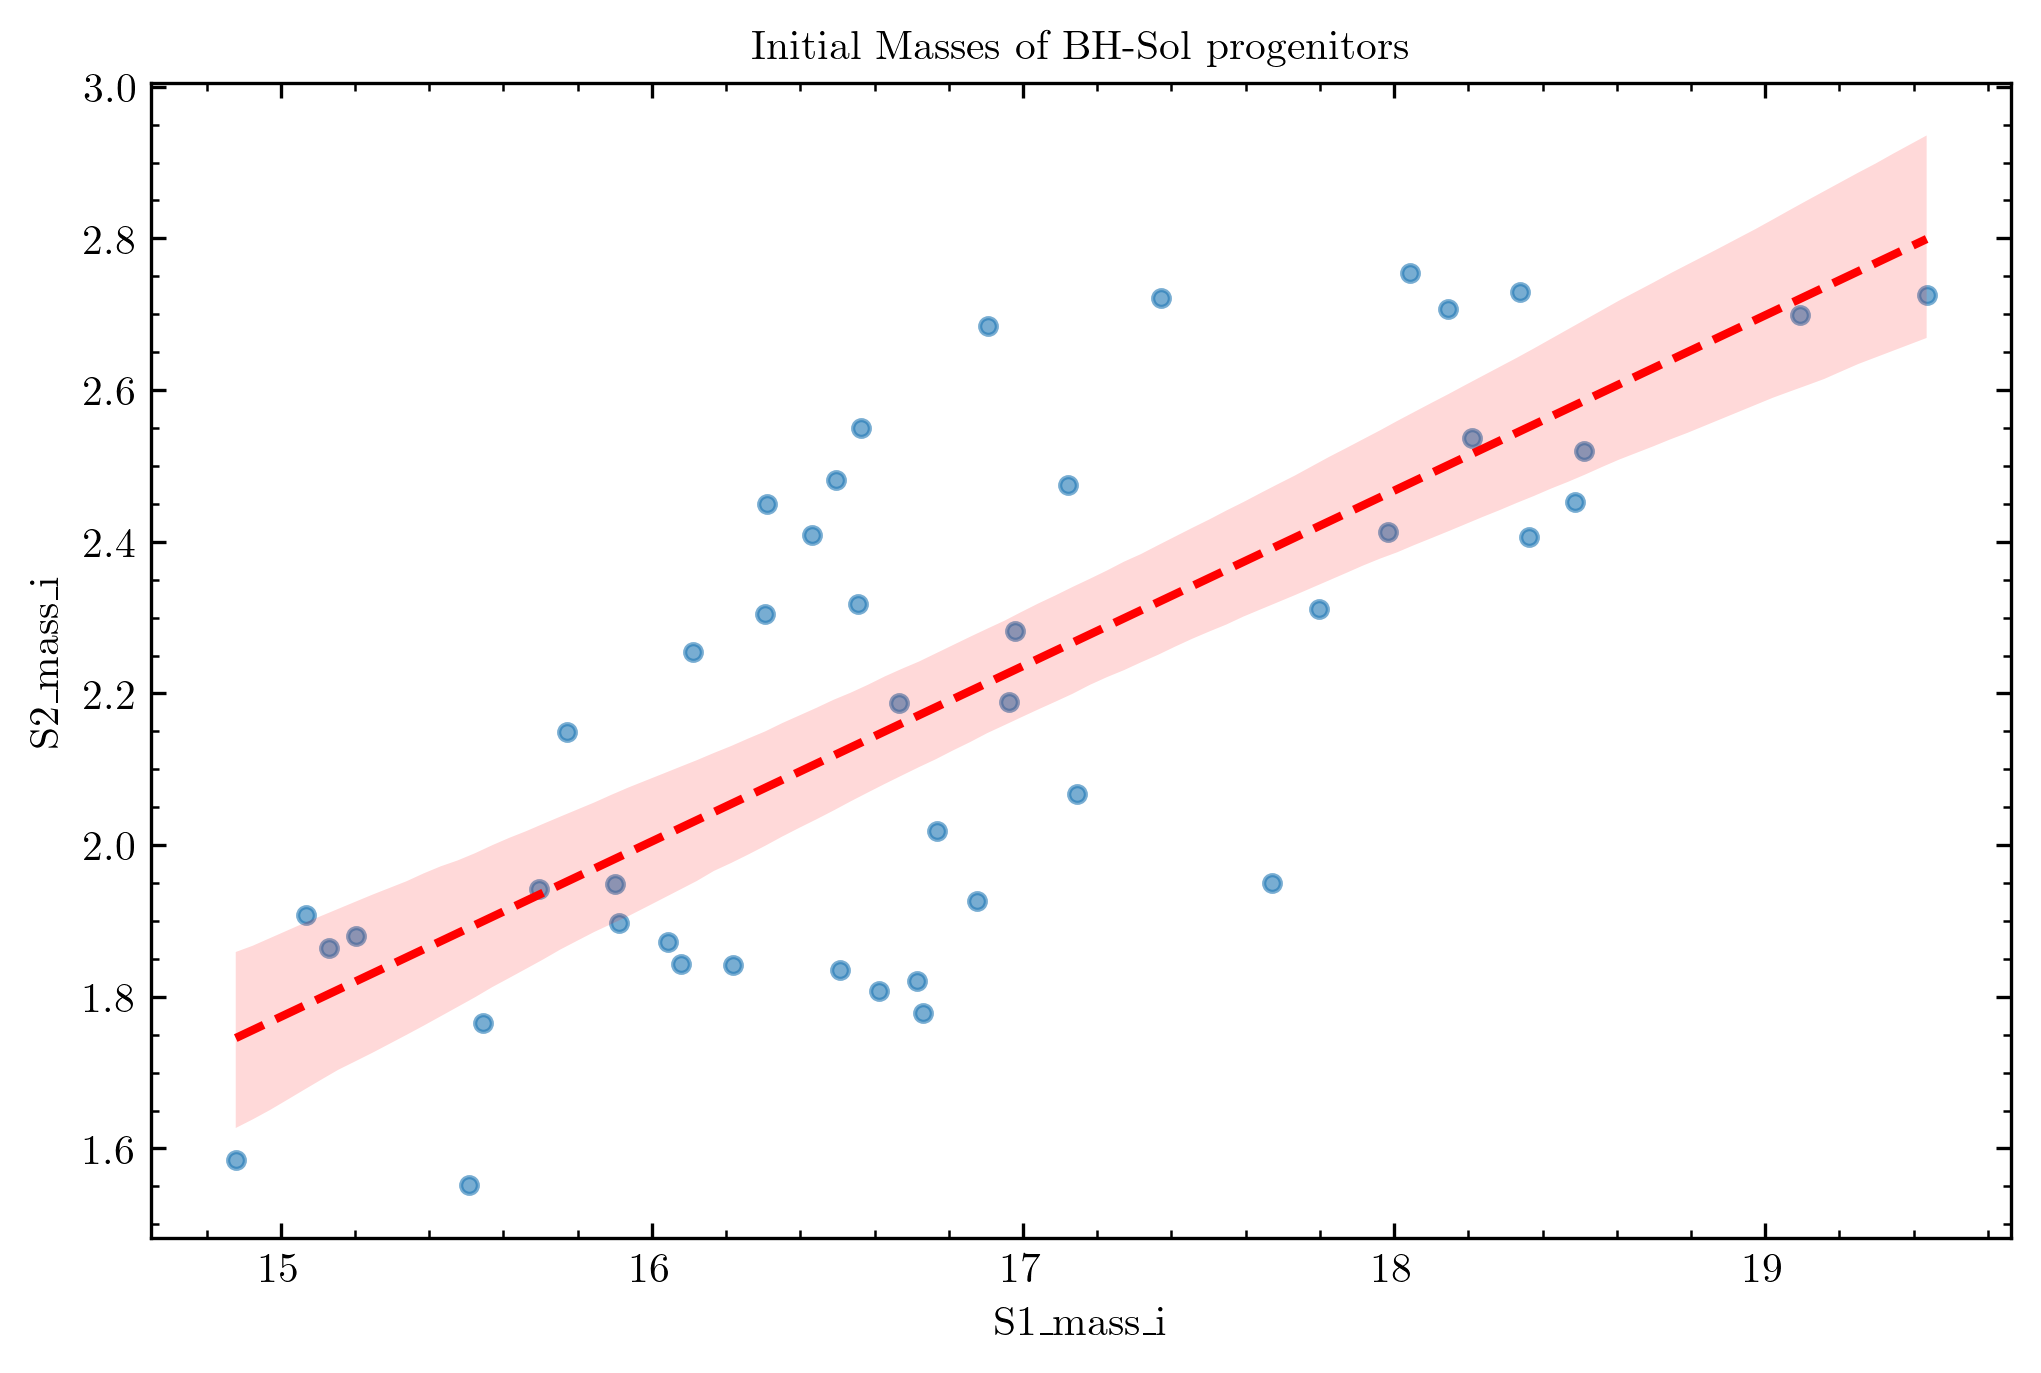

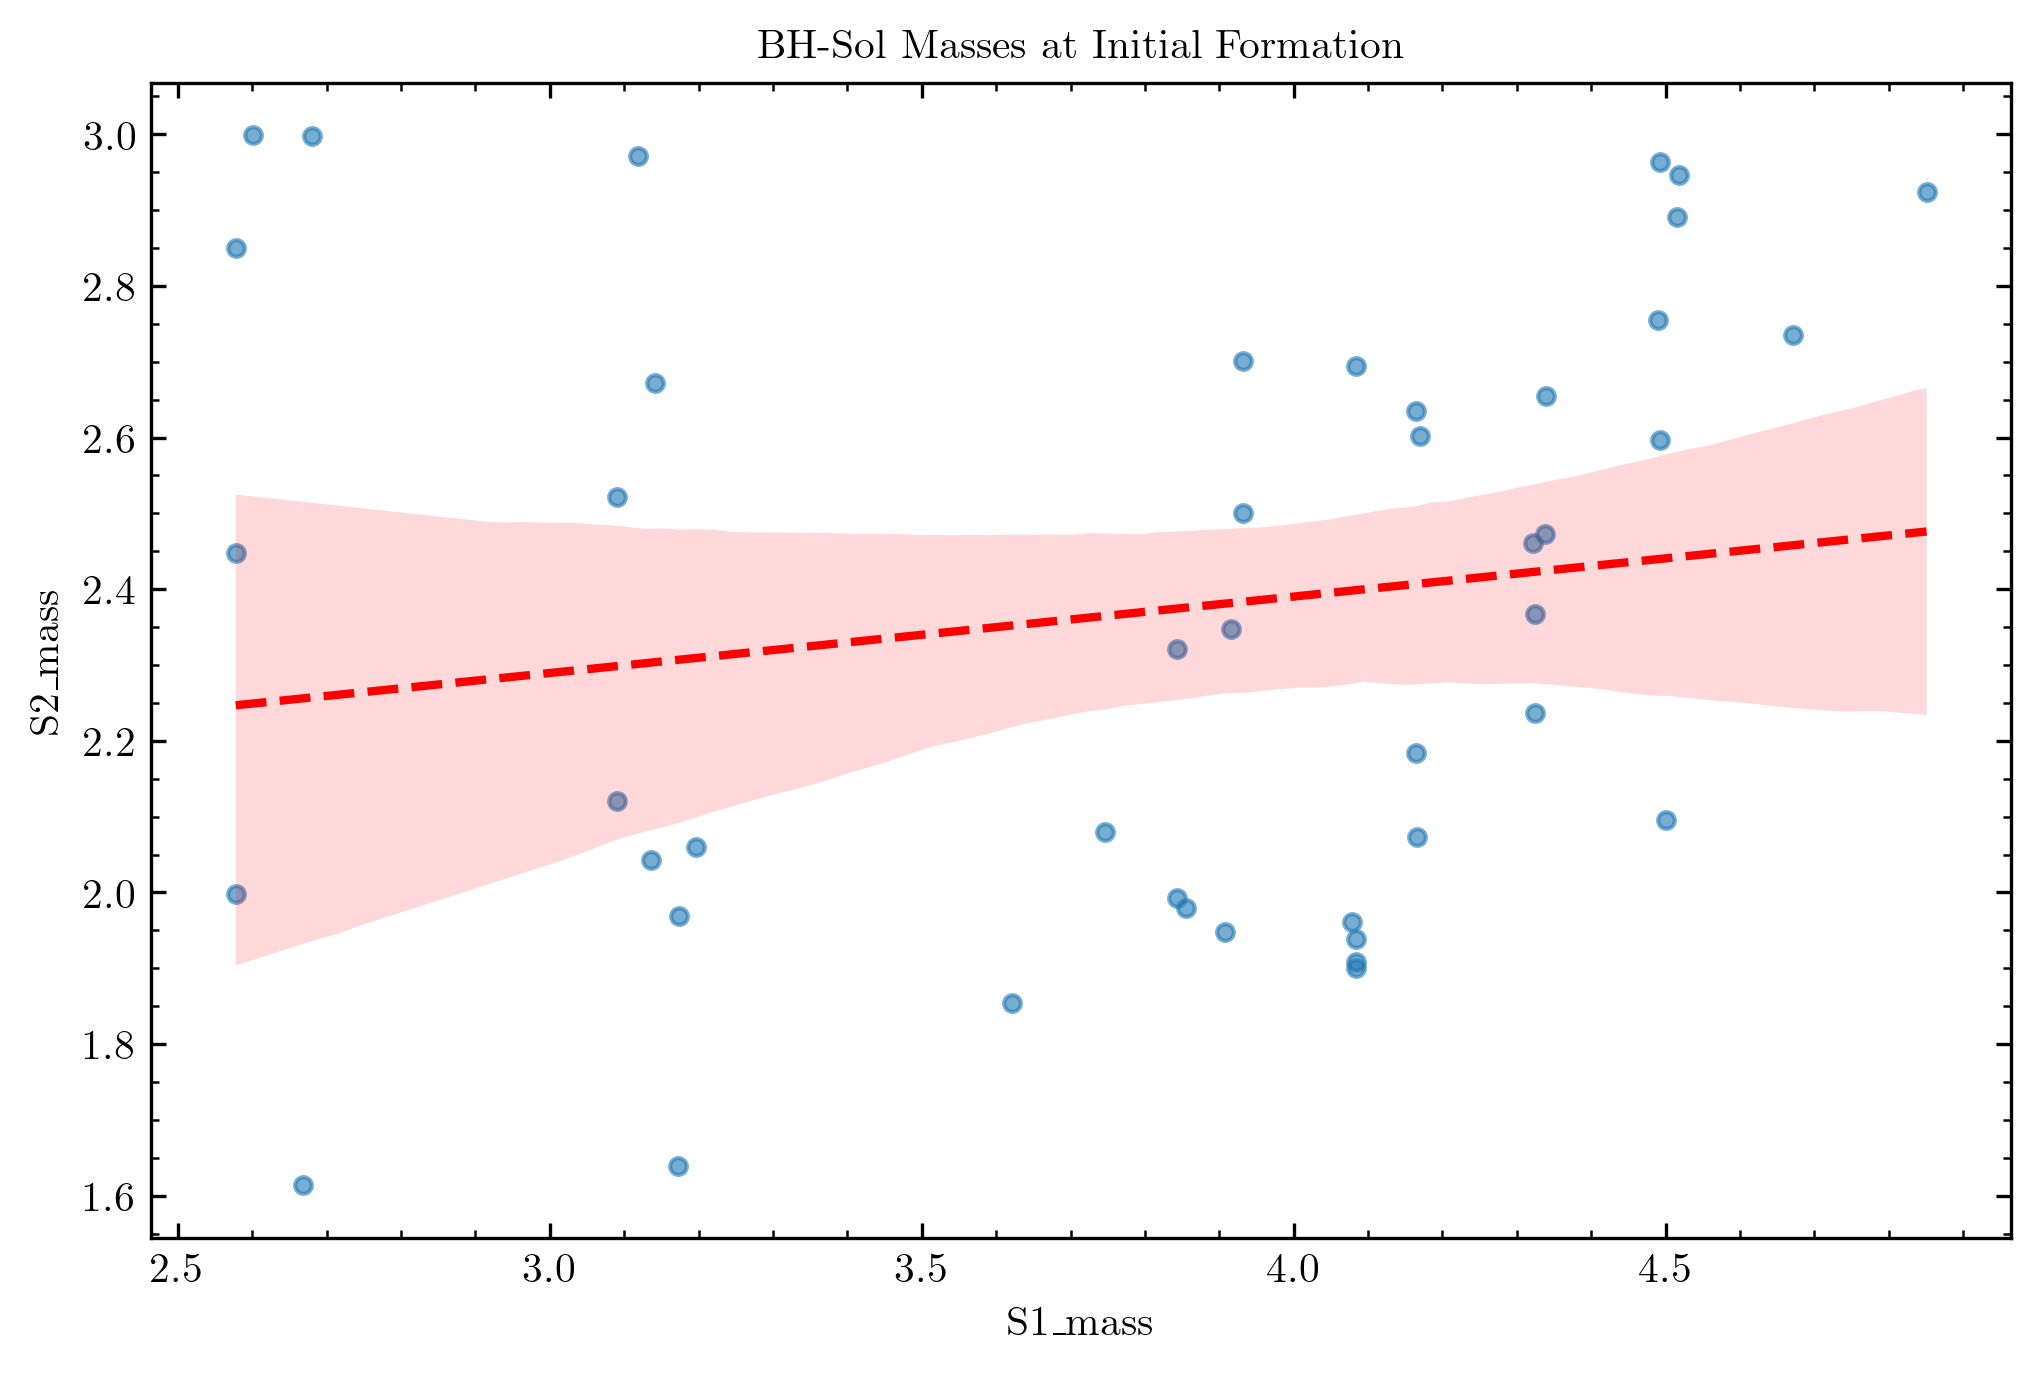

In [28]:
xVsY(df = pOneline, xvar= 'S1_mass_i', yvar='S2_mass_i', title='Initial Masses of BH-Sol progenitors', fit=True, saveFig=False, savePath=graphSave)

xVsY(df = bhSolRows, xvar= 'S1_mass', yvar='S2_mass', title='BH-Sol Masses at Initial Formation', fit=True, saveFig=False, savePath=graphSave)

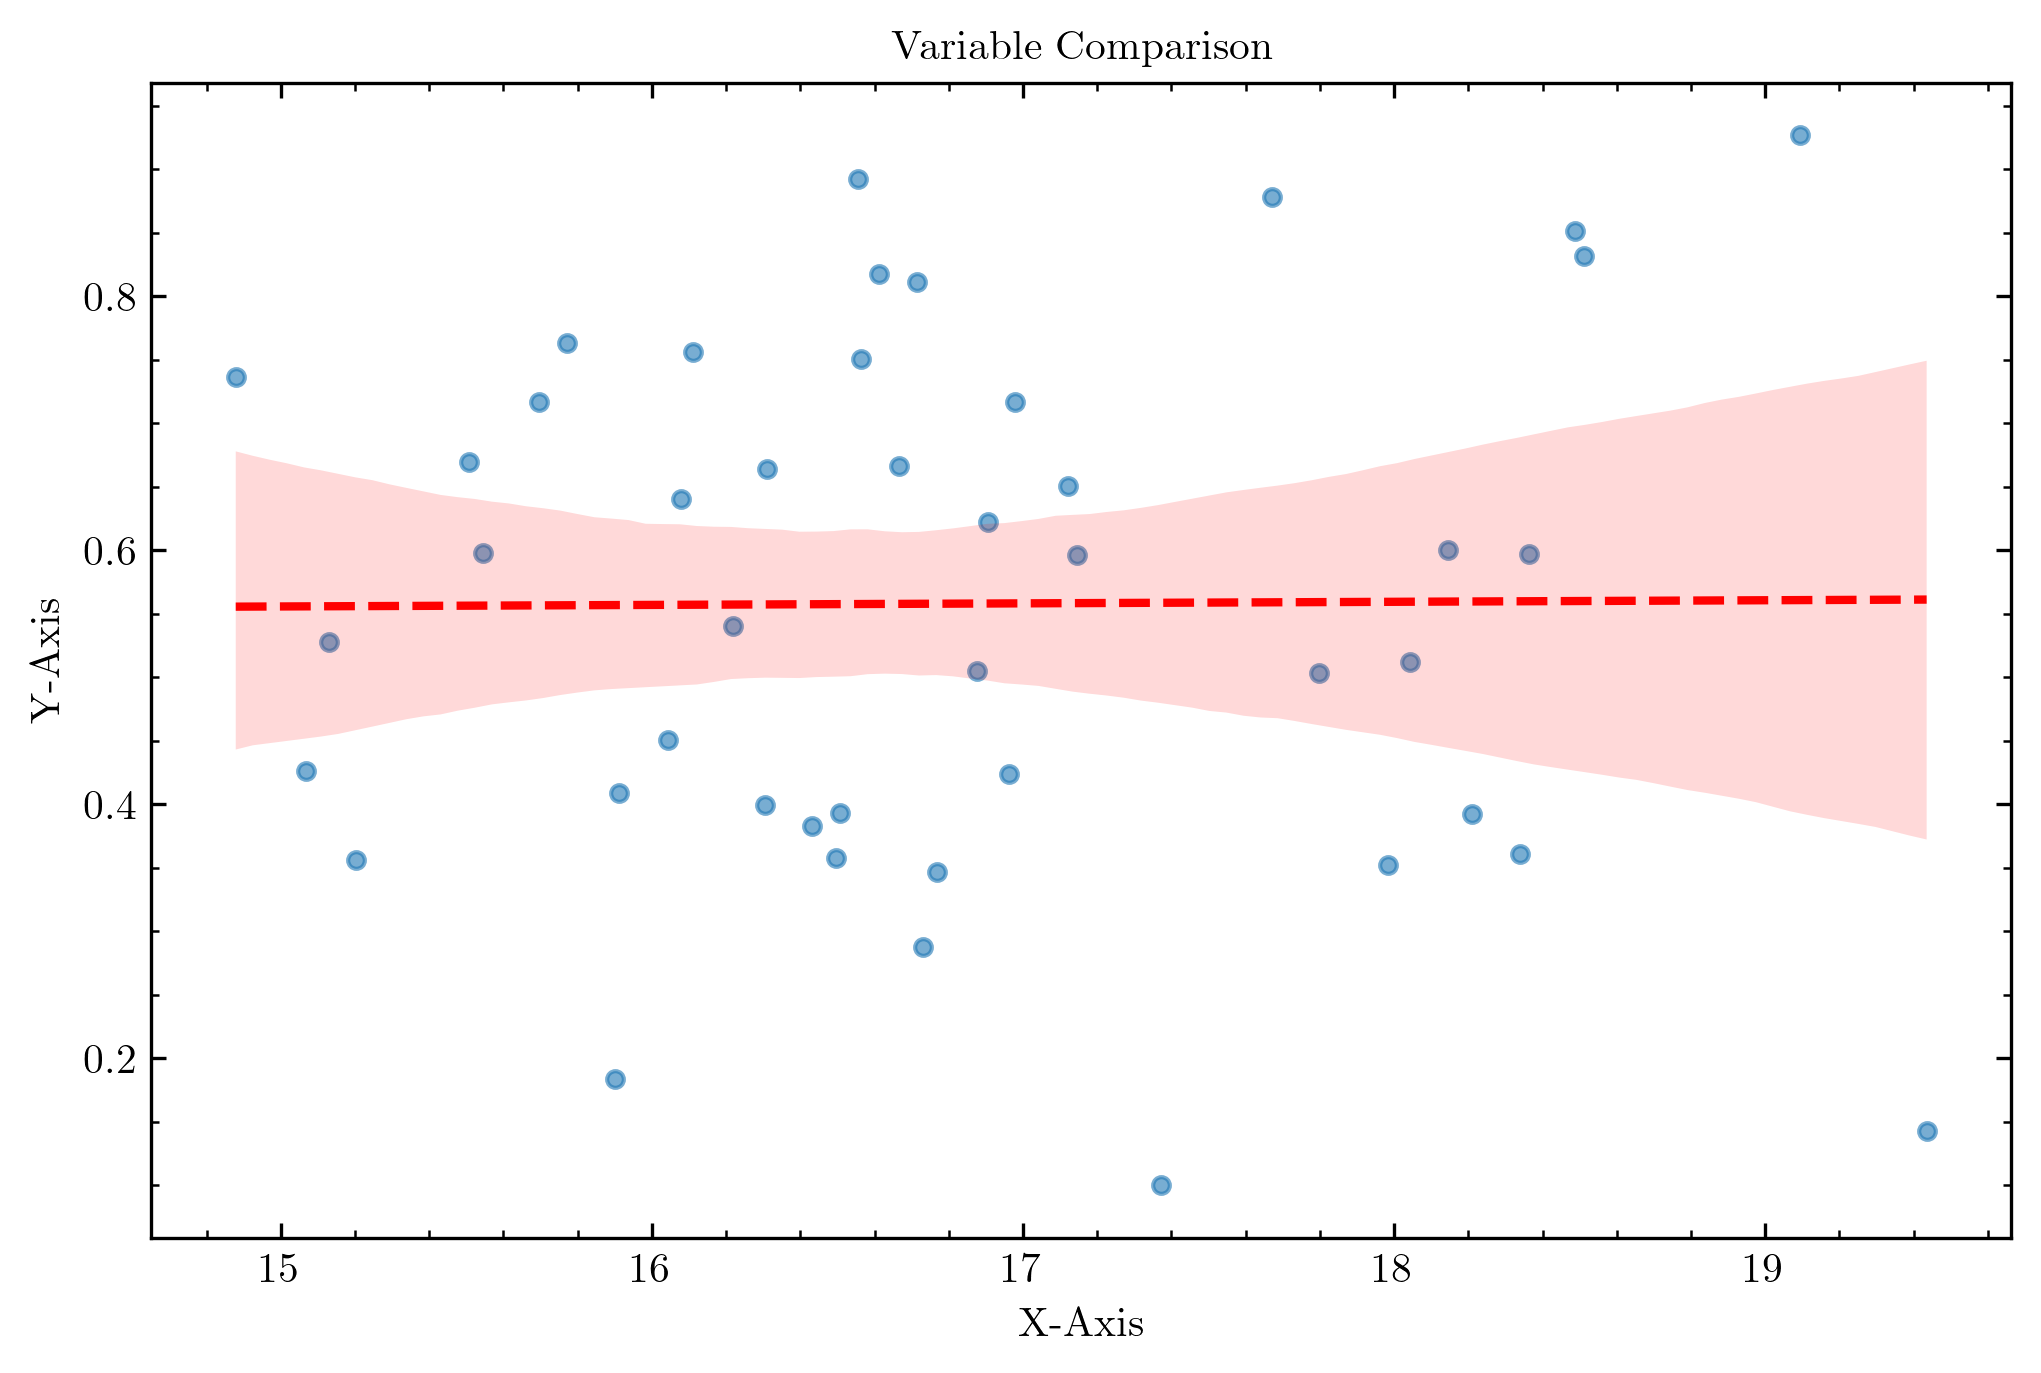

In [29]:
xVsY(useDF=False, xvar=pOneline['S1_mass_i'], yvar=bhSolRows['eccentricity'], fit=True)

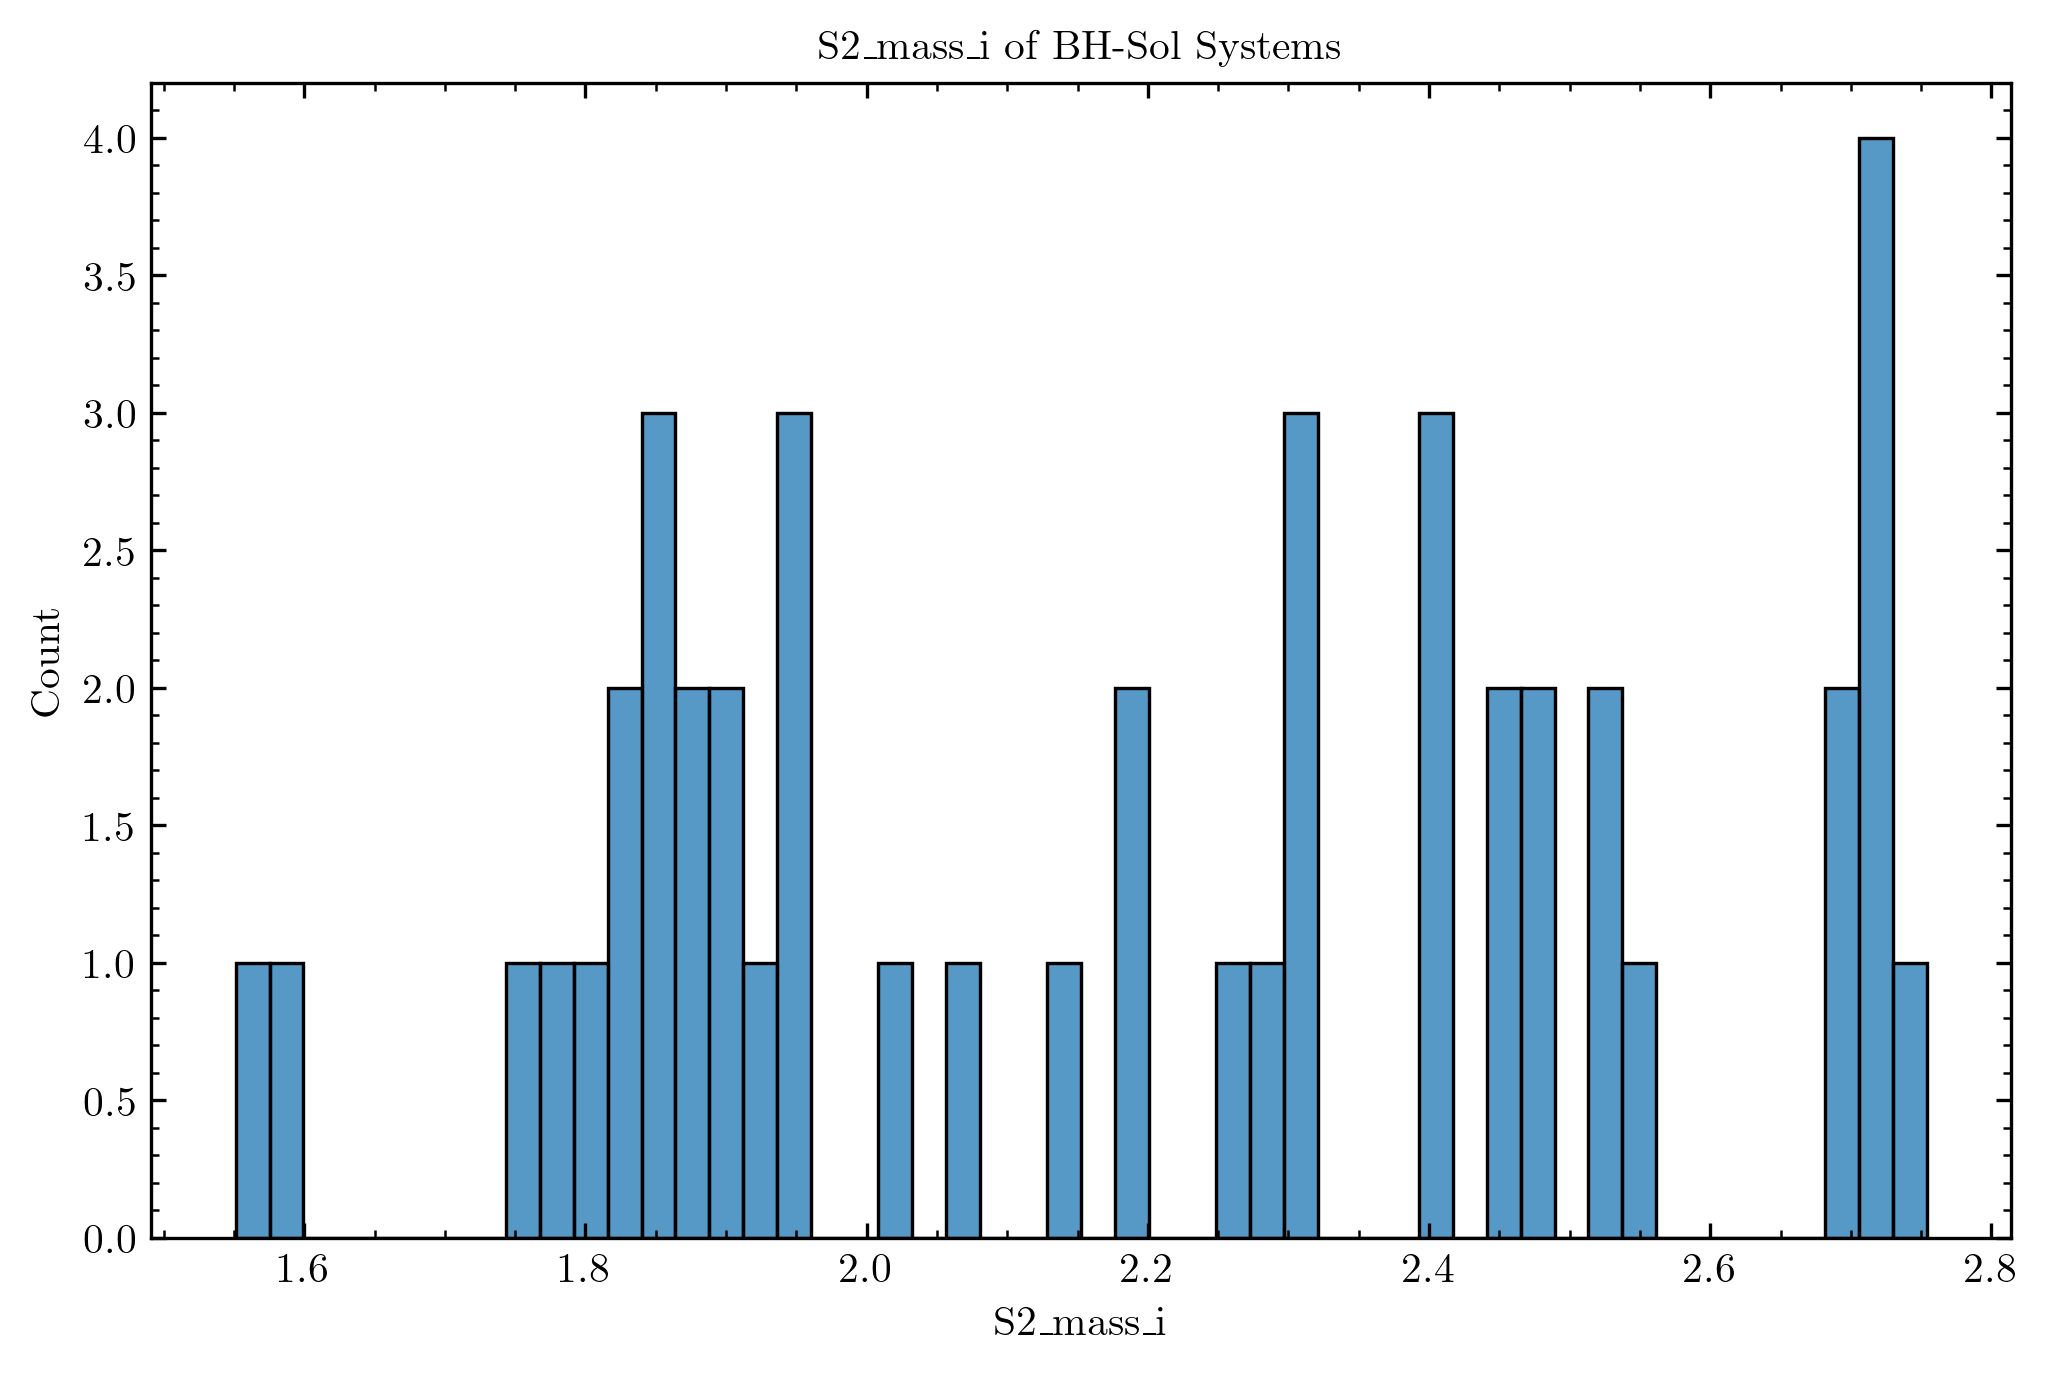

In [30]:
fig, ax = plt.subplots(figsize=(8,5))

var = 'S2_mass_i'
sns.histplot(pOneline[var], bins=50, ax=ax)

title = f'{var} of BH-Sol Systems'

ax.set_title(title)
ax.set_xlabel(var)
ax.set_ylabel('Count')

clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
plt.savefig(graphSave / clean_name, bbox_inches='tight')

plt.show()

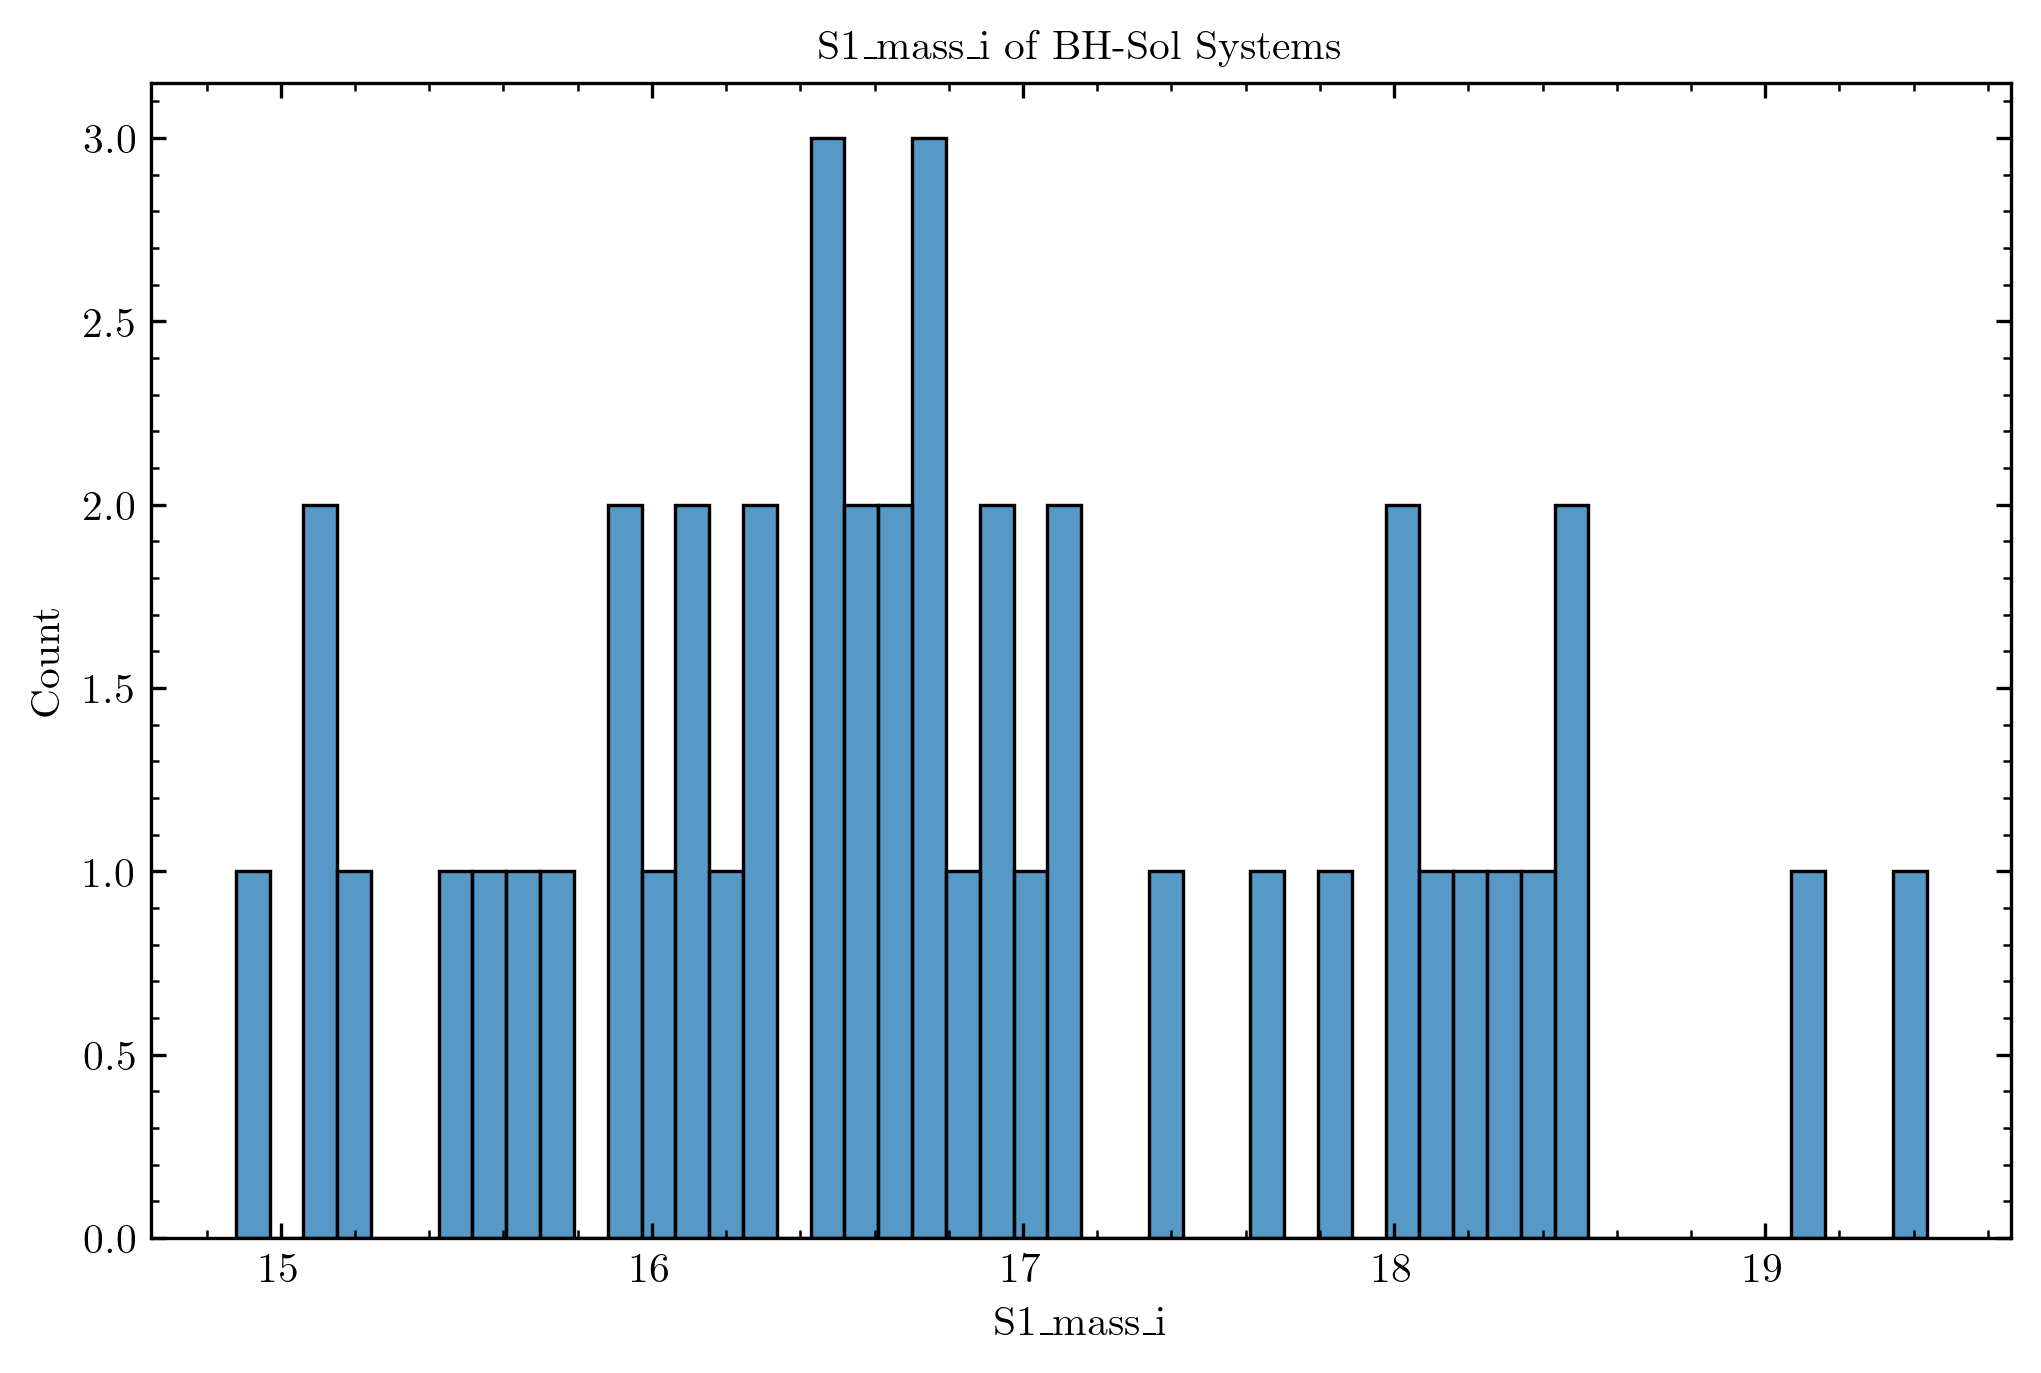

In [31]:
fig, ax = plt.subplots(figsize=(8,5))

var = 'S1_mass_i'
sns.histplot(pOneline[var], bins=50, ax=ax)

title = f'{var} of BH-Sol Systems'

ax.set_title(title)
ax.set_xlabel(var)
ax.set_ylabel('Count')

clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
plt.savefig(graphSave / clean_name, bbox_inches='tight')

plt.show()